In [1]:
import os
os.chdir(r"D:\Projects\Poverty Predictor Bd")

import ee
ee.Initialize(project='poverty-prediction-489716')
print("GEE initialized!")

GEE initialized!


In [2]:
# Load Bangladesh districts from FAO (same as before)
districts_fc = ee.FeatureCollection('FAO/GAUL/2015/level2') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))

print(f"Districts loaded: {districts_fc.size().getInfo()}")

# Get the bounding box of Bangladesh
bangladesh = ee.FeatureCollection('FAO/GAUL/2015/level0') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))

print("Bangladesh boundary loaded!")

Districts loaded: 64
Bangladesh boundary loaded!


In [3]:
def get_s2_composite(district_geometry, year=2022):
    """
    Get a cloud-free Sentinel-2 median composite for a district.
    Bands: B4 (Red), B3 (Green), B2 (Blue), B8 (NIR)
    """
    start = f'{year}-11-01'  # Nov-Feb = dry season = fewer clouds in Bangladesh
    end   = f'{year+1}-03-01'
    
    s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(district_geometry) \
        .filterDate(start, end) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
        .select(['B4', 'B3', 'B2', 'B8']) \
        .median() \
        .divide(10000)  # Scale to 0-1 reflectance
    
    return s2

# Test on one district first
test_district = districts_fc \
    .filter(ee.Filter.eq('ADM2_NAME', 'Dhaka')) \
    .first()

test_geom   = test_district.geometry()
test_image  = get_s2_composite(test_geom)

print("Band names:", test_image.bandNames().getInfo())
print("Test image info:", test_image.getInfo()['bands'][0])

Band names: ['B4', 'B3', 'B2', 'B8']
Test image info: {'id': 'B4', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}


In [5]:
# Always test with one district before running all 64
task_test = ee.batch.Export.image.toDrive(
    image=test_image.clip(test_geom),
    description='s2_test_dhaka',
    folder='GEE_exports',
    fileNamePrefix='s2_dhaka_2022',
    region=test_geom,
    scale=10,          # Sentinel-2 native resolution = 10m
    crs='EPSG:4326',
    fileFormat='GeoTIFF',
    maxPixels=1e9
)
task_test.start()
print(f"Test export started: {task_test.status()['state']}")
print("Monitor at: https://code.earthengine.google.com/tasks")

Test export started: READY
Monitor at: https://code.earthengine.google.com/tasks


Shape:      (5793, 5665)
Bands:      4  (B4=Red, B3=Green, B2=Blue, B8=NIR)
CRS:        EPSG:4326
Resolution: (8.983152841195215e-05, 8.983152841195215e-05) degrees
Bounds:     BoundingBox(left=90.00499309331563, bottom=23.52373318759585, right=90.51388870176935, top=24.04412723168629)

Value ranges (should be 0-1):
  Red:  nan — nan
  Green:nan — nan
  Blue: nan — nan
  NIR:  nan — nan

Null/zero pixels: 0 / 32817345 (0.0%)


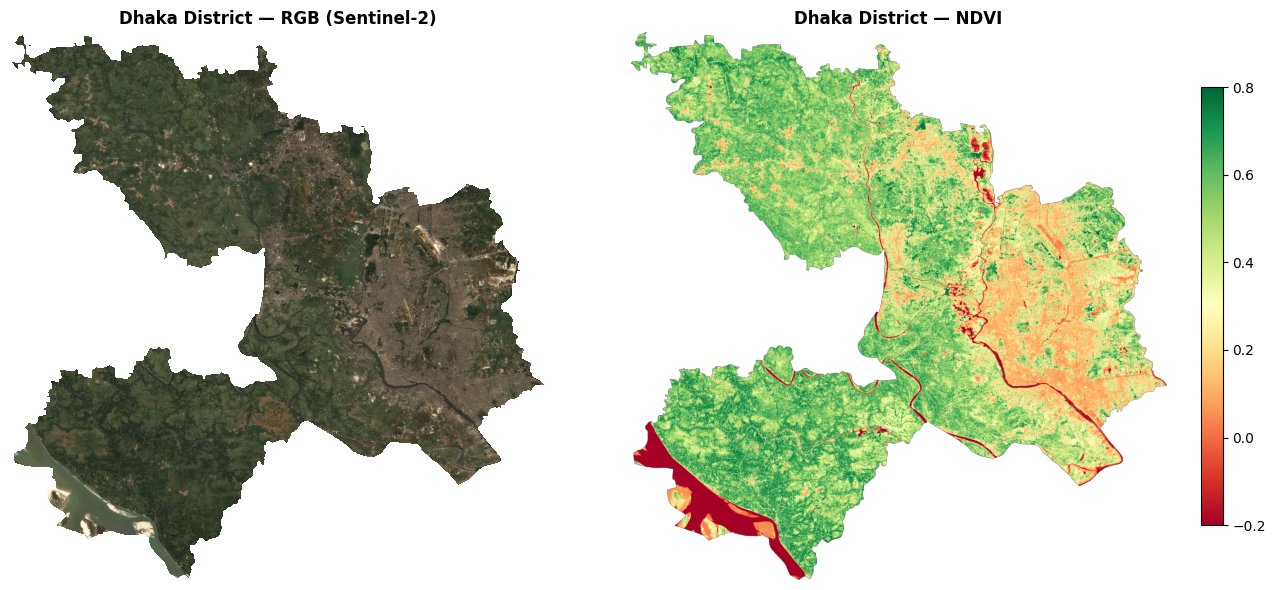


File size: 368.0 MB
Estimated total for 64 districts: 23552 MB


In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# First download s2_dhaka_2022.tif from Google Drive
# Save it to data/raw/sentinel2_test/s2_dhaka_2022.tif
# Then run this cell

tif_path = "data/raw/sentinel2_test/s2_dhaka_2022.tif"

with rasterio.open(tif_path) as src:
    print(f"Shape:      {src.shape}")
    print(f"Bands:      {src.count}  (B4=Red, B3=Green, B2=Blue, B8=NIR)")
    print(f"CRS:        {src.crs}")
    print(f"Resolution: {src.res} degrees")
    print(f"Bounds:     {src.bounds}")
    
    # Read RGB bands (B4, B3, B2)
    r = src.read(1)
    g = src.read(2)
    b = src.read(3)
    n = src.read(4)  # NIR
    
    print(f"\nValue ranges (should be 0-1):")
    print(f"  Red:  {r.min():.4f} — {r.max():.4f}")
    print(f"  Green:{g.min():.4f} — {g.max():.4f}")
    print(f"  Blue: {b.min():.4f} — {b.max():.4f}")
    print(f"  NIR:  {n.min():.4f} — {n.max():.4f}")
    
    print(f"\nNull/zero pixels: {(r == 0).sum()} / {r.size} "
          f"({100*(r==0).sum()/r.size:.1f}%)")

# Visualize RGB
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RGB composite — brighten for visualization
rgb = np.stack([r, g, b], axis=-1)
rgb_bright = np.clip(rgb * 3.5, 0, 1)  # stretch contrast
axes[0].imshow(rgb_bright)
axes[0].set_title('Dhaka District — RGB (Sentinel-2)', fontweight='bold')
axes[0].axis('off')

# NDVI = (NIR - Red) / (NIR + Red)
ndvi = (n - r) / (n + r + 1e-8)
im = axes[1].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[1].set_title('Dhaka District — NDVI', fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig("outputs/figures/sentinel2_dhaka_test.png", dpi=150, bbox_inches='tight')
plt.show()

# File size
import os
size_mb = os.path.getsize(tif_path) / (1024*1024)
print(f"\nFile size: {size_mb:.1f} MB")
print(f"Estimated total for 64 districts: {size_mb*64:.0f} MB")

In [7]:
task_test2 = ee.batch.Export.image.toDrive(
    image=test_image.clip(test_geom).unmask(0),
    description='s2_test_dhaka_100m',
    folder='GEE_exports',
    fileNamePrefix='s2_dhaka_2022_100m',
    region=test_geom,
    scale=100,         # 100m instead of 10m
    crs='EPSG:4326',
    fileFormat='GeoTIFF',
    maxPixels=1e9
)
task_test2.start()
print(f"100m test export started: {task_test2.status()['state']}")

100m test export started: READY


Shape:      (580, 567)
Resolution: (0.0008983152841195215, 0.0008983152841195215)

Value ranges:
  Red:  0.0269 — 0.4125
  Green:0.0336 — 0.3915
  Blue: 0.0213 — 0.3494
  NIR:  0.0182 — 0.4711

File size:   3.93 MB
Est. 64 districts: 252 MB


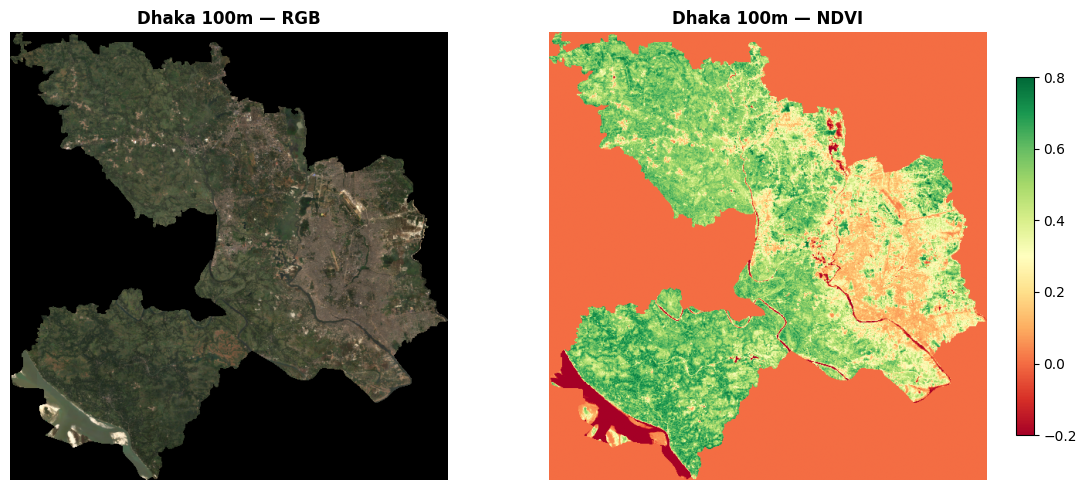

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

tif_path = "data/raw/sentinel2_test/s2_dhaka_2022_100m.tif"

with rasterio.open(tif_path) as src:
    print(f"Shape:      {src.shape}")
    print(f"Resolution: {src.res}")
    
    r = src.read(1).astype(float)
    g = src.read(2).astype(float)
    b = src.read(3).astype(float)
    n = src.read(4).astype(float)
    
    # Replace 0s (masked areas) with nan for stats
    r[r == 0] = np.nan
    g[g == 0] = np.nan
    b[b == 0] = np.nan
    n[n == 0] = np.nan
    
    print(f"\nValue ranges:")
    print(f"  Red:  {np.nanmin(r):.4f} — {np.nanmax(r):.4f}")
    print(f"  Green:{np.nanmin(g):.4f} — {np.nanmax(g):.4f}")
    print(f"  Blue: {np.nanmin(b):.4f} — {np.nanmax(b):.4f}")
    print(f"  NIR:  {np.nanmin(n):.4f} — {np.nanmax(n):.4f}")

size_mb = os.path.getsize(tif_path) / (1024*1024)
print(f"\nFile size:   {size_mb:.2f} MB")
print(f"Est. 64 districts: {size_mb*64:.0f} MB")

# Quick visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rgb = np.stack([
    np.nan_to_num(r), 
    np.nan_to_num(g), 
    np.nan_to_num(b)], axis=-1)
rgb_bright = np.clip(rgb * 3.5, 0, 1)
axes[0].imshow(rgb_bright)
axes[0].set_title('Dhaka 100m — RGB', fontweight='bold')
axes[0].axis('off')

ndvi = (np.nan_to_num(n) - np.nan_to_num(r)) / \
       (np.nan_to_num(n) + np.nan_to_num(r) + 1e-8)
im = axes[1].imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[1].set_title('Dhaka 100m — NDVI', fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig("outputs/figures/sentinel2_dhaka_100m_test.png", 
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
import time

# Get all district names and geometries
districts_list = districts_fc.toList(districts_fc.size())
n_districts = districts_fc.size().getInfo()

tasks = []
failed = []

print(f"Queuing {n_districts} district exports...\n")

for i in range(n_districts):
    feature    = ee.Feature(districts_list.get(i))
    name       = feature.get('ADM2_NAME').getInfo()
    division   = feature.get('ADM1_NAME').getInfo()
    geom       = feature.geometry()
    
    # Clean name for filename
    safe_name  = name.replace("'", "").replace(" ", "_").lower()
    
    image = get_s2_composite(geom).clip(geom).unmask(0)
    
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=f's2_{safe_name}',
        folder='GEE_exports/sentinel2_districts',
        fileNamePrefix=f's2_{safe_name}_2022',
        region=geom,
        scale=100,
        crs='EPSG:4326',
        fileFormat='GeoTIFF',
        maxPixels=1e9
    )
    
    try:
        task.start()
        tasks.append({'district': name, 'division': division,
                      'task': task, 'safe_name': safe_name})
        print(f"  [{i+1:2}/64] ✓ Queued: {name}")
    except Exception as e:
        failed.append(name)
        print(f"  [{i+1:2}/64] ✗ Failed to queue: {name} — {e}")
    
    # Small delay to avoid overwhelming GEE API
    time.sleep(0.5)

print(f"\nQueued: {len(tasks)} / {n_districts}")
print(f"Failed: {len(failed)}")
if failed:
    print(f"Failed districts: {failed}")

Queuing 64 district exports...

  [ 1/64] ✓ Queued: Barisal
  [ 2/64] ✓ Queued: Bhola
  [ 3/64] ✓ Queued: Jhalokati
  [ 4/64] ✓ Queued: Patuakhali
  [ 5/64] ✓ Queued: Pirojpur
  [ 6/64] ✓ Queued: Bandarban
  [ 7/64] ✓ Queued: Brahamanbaria
  [ 8/64] ✓ Queued: Chandpur
  [ 9/64] ✓ Queued: Chittagong
  [10/64] ✓ Queued: Comilla
  [11/64] ✓ Queued: Cox's Bazar
  [12/64] ✓ Queued: Feni
  [13/64] ✓ Queued: Khagrachhari
  [14/64] ✓ Queued: Lakshmipur
  [15/64] ✓ Queued: Noakhali
  [16/64] ✓ Queued: Rangamati
  [17/64] ✓ Queued: Dhaka
  [18/64] ✓ Queued: Faridpur
  [19/64] ✓ Queued: Gazipur
  [20/64] ✓ Queued: Gopalganj
  [21/64] ✓ Queued: Jamalpur
  [22/64] ✓ Queued: Kishoreganj
  [23/64] ✓ Queued: Madaripur
  [24/64] ✓ Queued: Manikganj
  [25/64] ✓ Queued: Munshiganj
  [26/64] ✓ Queued: Mymensingh
  [27/64] ✓ Queued: Narayanganj
  [28/64] ✓ Queued: Narsingdi
  [29/64] ✓ Queued: Netrakona
  [30/64] ✓ Queued: Rajbari
  [31/64] ✓ Queued: Shariatpur
  [32/64] ✓ Queued: Sherpur
  [33/64] ✓ Queue

In [15]:
# Run this cell every 15-20 minutes to check status
from collections import Counter

statuses = []
for t in tasks:
    state = t['task'].status()['state']
    statuses.append(state)

counts = Counter(statuses)
print(f"Progress update:")
print(f"  COMPLETED:  {counts.get('COMPLETED', 0):3} / {len(tasks)}")
print(f"  RUNNING:    {counts.get('RUNNING', 0):3}")
print(f"  READY:      {counts.get('READY', 0):3}")
print(f"  FAILED:     {counts.get('FAILED', 0):3}")

# Show any failures
for t in tasks:
    state = t['task'].status()['state']
    if state == 'FAILED':
        print(f"  FAILED: {t['district']} — {t['task'].status().get('error_message','')}")

Progress update:
  COMPLETED:   64 / 64
  RUNNING:      0
  READY:        0
  FAILED:       0


In [16]:
import os
import rasterio
import numpy as np
import pandas as pd

sentinel2_dir = "data/raw/sentinel2"
tif_files = sorted([f for f in os.listdir(sentinel2_dir) 
                    if f.endswith('.tif')])

print(f"Files found: {len(tif_files)} / 64\n")

report = []
issues = []

for fname in tif_files:
    path = os.path.join(sentinel2_dir, fname)
    try:
        with rasterio.open(path) as src:
            r = src.read(1).astype(float)
            r[r == 0] = np.nan
            
            size_mb    = os.path.getsize(path) / (1024*1024)
            null_pct   = 100 * np.isnan(r).sum() / r.size
            valid_mean = np.nanmean(r)
            
            # Flag potential issues
            issue = None
            if null_pct > 50:
                issue = f"HIGH NULL {null_pct:.0f}%"
            elif size_mb < 0.5:
                issue = f"TOO SMALL {size_mb:.1f}MB"
            elif valid_mean > 0.4:
                issue = f"BRIGHT (cloud?) {valid_mean:.3f}"
            
            report.append({
                'file':       fname,
                'shape':      f"{src.shape[0]}x{src.shape[1]}",
                'size_mb':    round(size_mb, 2),
                'null_pct':   round(null_pct, 1),
                'valid_mean': round(valid_mean, 4),
                'issue':      issue or 'OK'
            })
            
            if issue:
                issues.append(fname)
                
    except Exception as e:
        report.append({'file': fname, 'issue': f'ERROR: {e}'})
        issues.append(fname)

df_report = pd.DataFrame(report)
print(df_report[['file','shape','size_mb','null_pct','issue']].to_string())

print(f"\n{'='*50}")
print(f"Total files:     {len(tif_files)}")
print(f"Total size:      {df_report['size_mb'].sum():.0f} MB")
print(f"Files with issues: {len(issues)}")
if issues:
    print(f"Problem files:   {issues}")
else:
    print("All files look good!")

Files found: 64 / 64

                         file      shape  size_mb  null_pct          issue
0        s2_bagerhat_2022.tif   1415x490     9.78      41.5             OK
1       s2_bandarban_2022.tif   1298x692    11.75      43.9             OK
2         s2_barguna_2022.tif    712x525     3.82      58.0  HIGH NULL 58%
3         s2_barisal_2022.tif    692x788     6.72      48.8             OK
4           s2_bhola_2022.tif   1121x529     6.40      57.7  HIGH NULL 58%
5           s2_bogra_2022.tif    654x875     7.64      43.0             OK
6   s2_brahamanbaria_2022.tif    694x677     5.15      54.7  HIGH NULL 55%
7        s2_chandpur_2022.tif    568x547     4.58      39.5             OK
8      s2_chittagong_2022.tif  1254x1002    11.89      61.9  HIGH NULL 62%
9       s2_chuadanga_2022.tif    526x427     3.08      44.5             OK
10        s2_comilla_2022.tif    832x822     8.16      50.7  HIGH NULL 51%
11     s2_coxs_bazar_2022.tif   1312x577     5.86      70.1  HIGH NULL 70%
12 

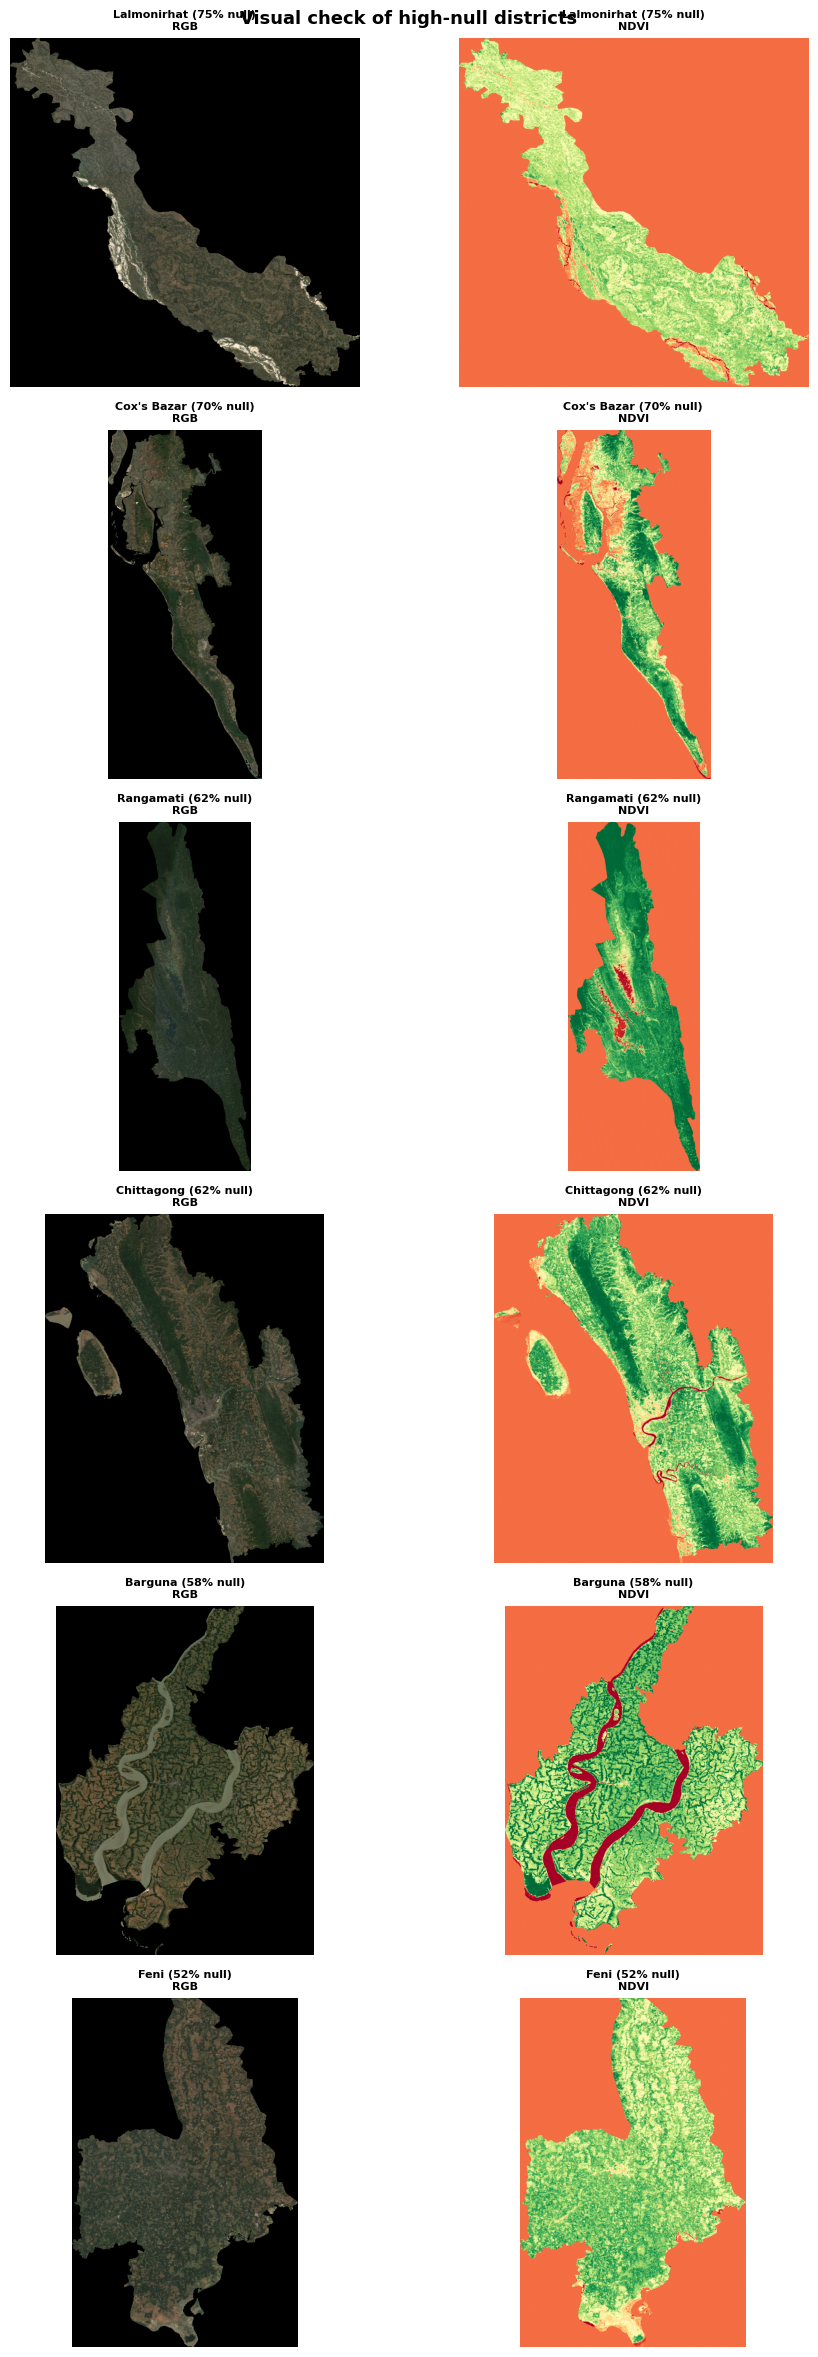

Saved: outputs/figures/sentinel2_spot_check.png


In [17]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_district(ax_rgb, ax_ndvi, path, title):
    with rasterio.open(path) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        n = src.read(4).astype(float)
    
    # Mask zeros
    mask = (r == 0) & (g == 0) & (b == 0)
    r[mask] = np.nan
    g[mask] = np.nan
    b[mask] = np.nan
    n[mask] = np.nan
    
    rgb = np.stack([np.nan_to_num(r), 
                    np.nan_to_num(g), 
                    np.nan_to_num(b)], axis=-1)
    rgb_bright = np.clip(rgb * 3.5, 0, 1)
    
    ndvi = (np.nan_to_num(n) - np.nan_to_num(r)) / \
           (np.nan_to_num(n) + np.nan_to_num(r) + 1e-8)
    ndvi[mask] = np.nan
    
    ax_rgb.imshow(rgb_bright)
    ax_rgb.set_title(f'{title}\nRGB', fontsize=8, fontweight='bold')
    ax_rgb.axis('off')
    
    im = ax_ndvi.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
    ax_ndvi.set_title(f'{title}\nNDVI', fontsize=8, fontweight='bold')
    ax_ndvi.axis('off')
    return im

# Check highest null% + a few coastal/delta districts
check_districts = [
    ('s2_lalmonirhat_2022.tif', 'Lalmonirhat (75% null)'),
    ('s2_coxs_bazar_2022.tif',  "Cox's Bazar (70% null)"),
    ('s2_rangamati_2022.tif',   'Rangamati (62% null)'),
    ('s2_chittagong_2022.tif',  'Chittagong (62% null)'),
    ('s2_barguna_2022.tif',     'Barguna (58% null)'),
    ('s2_feni_2022.tif',        'Feni (52% null)'),
]

fig, axes = plt.subplots(len(check_districts), 2, 
                          figsize=(10, 4*len(check_districts)))
fig.suptitle('Visual check of high-null districts', 
             fontsize=13, fontweight='bold')

sentinel2_dir = "data/raw/sentinel2"
for i, (fname, title) in enumerate(check_districts):
    path = os.path.join(sentinel2_dir, fname)
    plot_district(axes[i,0], axes[i,1], path, title)

plt.tight_layout()
plt.savefig("outputs/figures/sentinel2_spot_check.png", 
            dpi=120, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/sentinel2_spot_check.png")